In [2]:
import cv2
import time
from matplotlib import pyplot as plt

In [28]:
def camera_init():
    camera = cv2.VideoCapture(0, cv2.CAP_V4L2)
    camera.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
    camera.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    # Warm up once
    for _ in range(15):
        ret, frame = camera.read()
        if frame is not None and frame.max() > 0:
            break
        time.sleep(0.1)
    print("Camera ready:", ret and frame.max() > 0)

    return camera

def get_cam_image(camera, display=True):
    """Flush stale frames and capture a fresh one. Returns the BGR frame."""
    for _ in range(10):
        camera.grab()
    ret, frame = camera.read()
    if not ret or frame.max() <= 2:
        raise RuntimeError("Failed to capture a valid frame.")
    if display:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.title('USB Camera Capture')
        plt.axis('off')
        plt.show()
    return frame

def deinit_camera(camera):
    """Release the camera resource."""
    camera.release()
    time.sleep(2)  # give OS time to free /dev/video0
    print("Camera released.")

In [36]:
#Example usage

camera = camera_init()  #this one's weird. If this cell fails, run this cell again until it says "Camera ready: True"

Camera ready: True


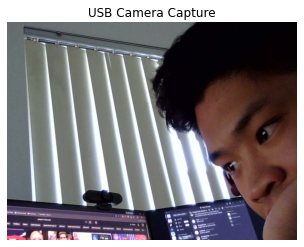

In [34]:
# Capture as many times as needed
frame = get_cam_image(camera)

In [35]:
deinit_camera(camera)

Camera released.
